# P1 · Select the values you mean

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.3 · Select the values you mean

Integer indexing removes an axis; slicing preserves it. Select targets without confusing their IDs with their scores.

**Prerequisites:** Read tensor axes

**Predict:** Which expression preserves a one-position time axis?

**Mental model:** Generation needs the prediction at the latest position, while training uses predictions at many positions. Selecting the right time axis is part of implementing that difference.

### P1.3.1 · Understand the need

Generation needs the prediction at the latest position, while training uses predictions at many positions. Selecting the right time axis is part of implementing that difference.

Two expressions can select equal values but return different shapes. An integer time index removes the axis; a one-position slice retains it.

Boolean indexing answers another question: which entries satisfy a condition? A mask over every axis collects selected entries into a single sequence.

Target IDs identify which candidate score to inspect. Gather selects those scores using an index tensor whose axes must match the operation.

Predict both values and shape before running an indexing expression. Either can reveal an incorrect assumption.

### P1.3.2 · Follow the values

Start with two examples, three time positions and four features. Unique integers identify every original coordinate.

Select the last time position with an integer index. Each example now has one vector of four features, with no time axis left.

Select the same position with a slice. The values match, but the shape still includes a time axis of length one.

Select even entries using a full Boolean mask. The result is a flat collection of the entries that passed the test.

Finally, gather candidate zero for the first score vector and candidate two for the second. The selected scores are two and two, held in a two-by-one tensor.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 3, 4)
show("[batch, time, features]", x)
position = -2 if change else -1
show("Integer time index", x[:, position, :])
show("Length-one time slice", x[:, position:position+1 if position != -1 else None, :])
show("Boolean selection of even entries", x[x % 2 == 0])
scores = torch.tensor([[2., 1., 0.], [0., 4., 2.]])
targets = torch.tensor([[0], [2]])
show("One selected score per example", scores.gather(1, targets))

[batch, time, features]: [[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]], [[12, 13, 14, 15], [16, 17, 18, 19], [20, 21, 22, 23]]]
  shape [2, 3, 4] · torch.int64 · cpu
Integer time index: [[8, 9, 10, 11], [20, 21, 22, 23]]
  shape [2, 4] · torch.int64 · cpu
Length-one time slice: [[[8, 9, 10, 11]], [[20, 21, 22, 23]]]
  shape [2, 1, 4] · torch.int64 · cpu
Boolean selection of even entries: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
  shape [12] · torch.int64 · cpu
One selected score per example: [[2.0], [2.0]]
  shape [2, 1] · torch.float32 · cpu


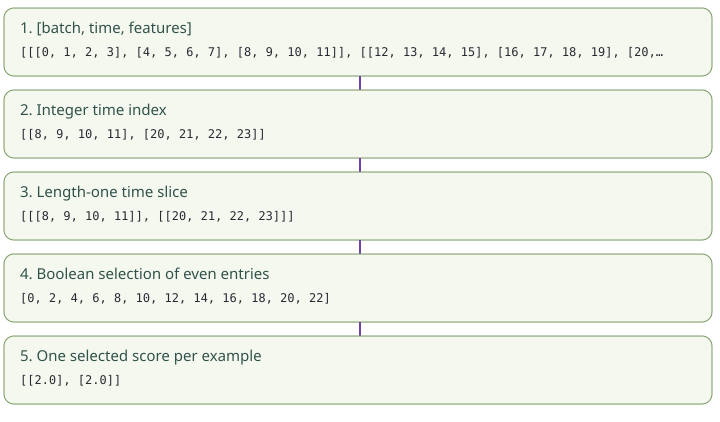

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

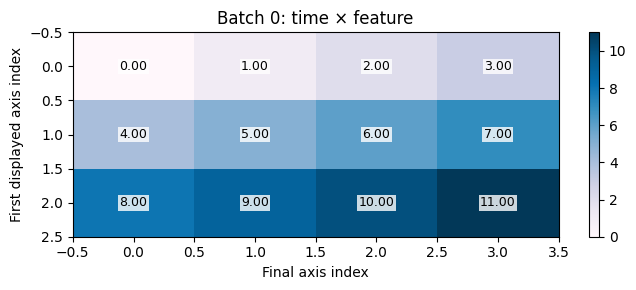

In [5]:
image = (x[0].float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Batch 0: time × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.3.3 · Read and run the code

A colon preserves all entries of an axis. The middle integer in the first selection removes only the time axis, leaving batch and feature axes.

The stop boundary of a slice remains exclusive. A slice ending at the sequence boundary can use None to include the last available position.

A tensor comparison produces a Boolean mask. Use tensor Boolean operations and explicit reductions instead of Python and over multiple tensor values.

Gather receives the selection axis and an integer index tensor. The index tensor retains the batch axis and adds a singleton selection axis here.

Item is suitable only after selecting one element. Converting a whole batch of results to a single Python scalar is a different and usually invalid request.

### Change one thing

**Select the previous time position**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 3, 4)
show("[batch, time, features]", x)
position = -2 if change else -1
show("Integer time index", x[:, position, :])
show("Length-one time slice", x[:, position:position+1 if position != -1 else None, :])
show("Boolean selection of even entries", x[x % 2 == 0])
scores = torch.tensor([[2., 1., 0.], [0., 4., 2.]])
targets = torch.tensor([[0], [2]])
show("One selected score per example", scores.gather(1, targets))

[batch, time, features]: [[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]], [[12, 13, 14, 15], [16, 17, 18, 19], [20, 21, 22, 23]]]
  shape [2, 3, 4] · torch.int64 · cpu
Integer time index: [[4, 5, 6, 7], [16, 17, 18, 19]]
  shape [2, 4] · torch.int64 · cpu
Length-one time slice: [[[4, 5, 6, 7]], [[16, 17, 18, 19]]]
  shape [2, 1, 4] · torch.int64 · cpu
Boolean selection of even entries: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
  shape [12] · torch.int64 · cpu
One selected score per example: [[2.0], [2.0]]
  shape [2, 1] · torch.float32 · cpu


### A useful distinction

The same selected values can have different shapes, which changes later broadcasting behavior.

### ✋ Your turn

Keep the last time position of x with shape [2,3,4], preserving all three axes; put its shape in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (2,1,4), 'The same selected values can have different shapes, which changes later broadcasting behavior.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
x = torch.arange(24).reshape(2,3,4)
answer = tuple(x[:, -1:, :].shape)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (2,1,4), 'The same selected values can have different shapes, which changes later broadcasting behavior.'
    print("✓ right:", answer)

✓ right: (2, 1, 4)


### P1.3.4 · Find it in the model

The model returns logits for every input position. Generation selects the final position before converting its candidate scores into probabilities.

Training compares every predicted position with its own next-character target. A target ID names a candidate along the vocabulary axis.

In attention, indexing a batch or head removes organizational axes while keeping a smaller matrix to inspect. The operation itself still runs on the full tensor.

Padding and causal masks select different kinds of validity. Their axes should make that purpose explicit.

Next, combine selected sequences into batches and distinguish adding an axis from extending an existing axis.

```python
logits, _ = self(idx[:, -self.cfg.block_size:])
probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which expression preserves a one-position time axis?

<details><summary>Check your explanation</summary>

x[:, -1:, :]. The same selected values can have different shapes, which changes later broadcasting behavior.

</details>